In [1]:
import sys, os
import matplotlib
import mne

print(sys.executable)
print(matplotlib.get_backend())
print(mne.__version__)
print("DISPLAY:", os.environ.get('DISPLAY', 'not set'))
print("interactive:", matplotlib.is_interactive())

import IPython
print("IPython:", IPython.get_ipython())

/home/alouis/mne_env/bin/python
module://matplotlib_inline.backend_inline
1.12.1
DISPLAY: not set
interactive: False
IPython: <ipykernel.zmqshell.ZMQInteractiveShell object at 0x1466b320f710>


/tmp/ipykernel_1147025/1404204245.py:11: RuntimeWarning: There are channels without locations (n/a) that are not marked as bad: ['EOG_L', 'EOG_R', 'EMG_chin', 'misc1', 'misc2', 'misc3']
  raw = read_raw_bids(bids_path, verbose=False)
/tmp/ipykernel_1147025/1404204245.py:11: RuntimeWarning: Not setting positions of 6 emg/eog/misc channels found in montage:
['EOG_L', 'EOG_R', 'EMG_chin', 'misc1', 'misc2', 'misc3']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = read_raw_bids(bids_path, verbose=False)


Premier S1 à 270.0s (0.07h)


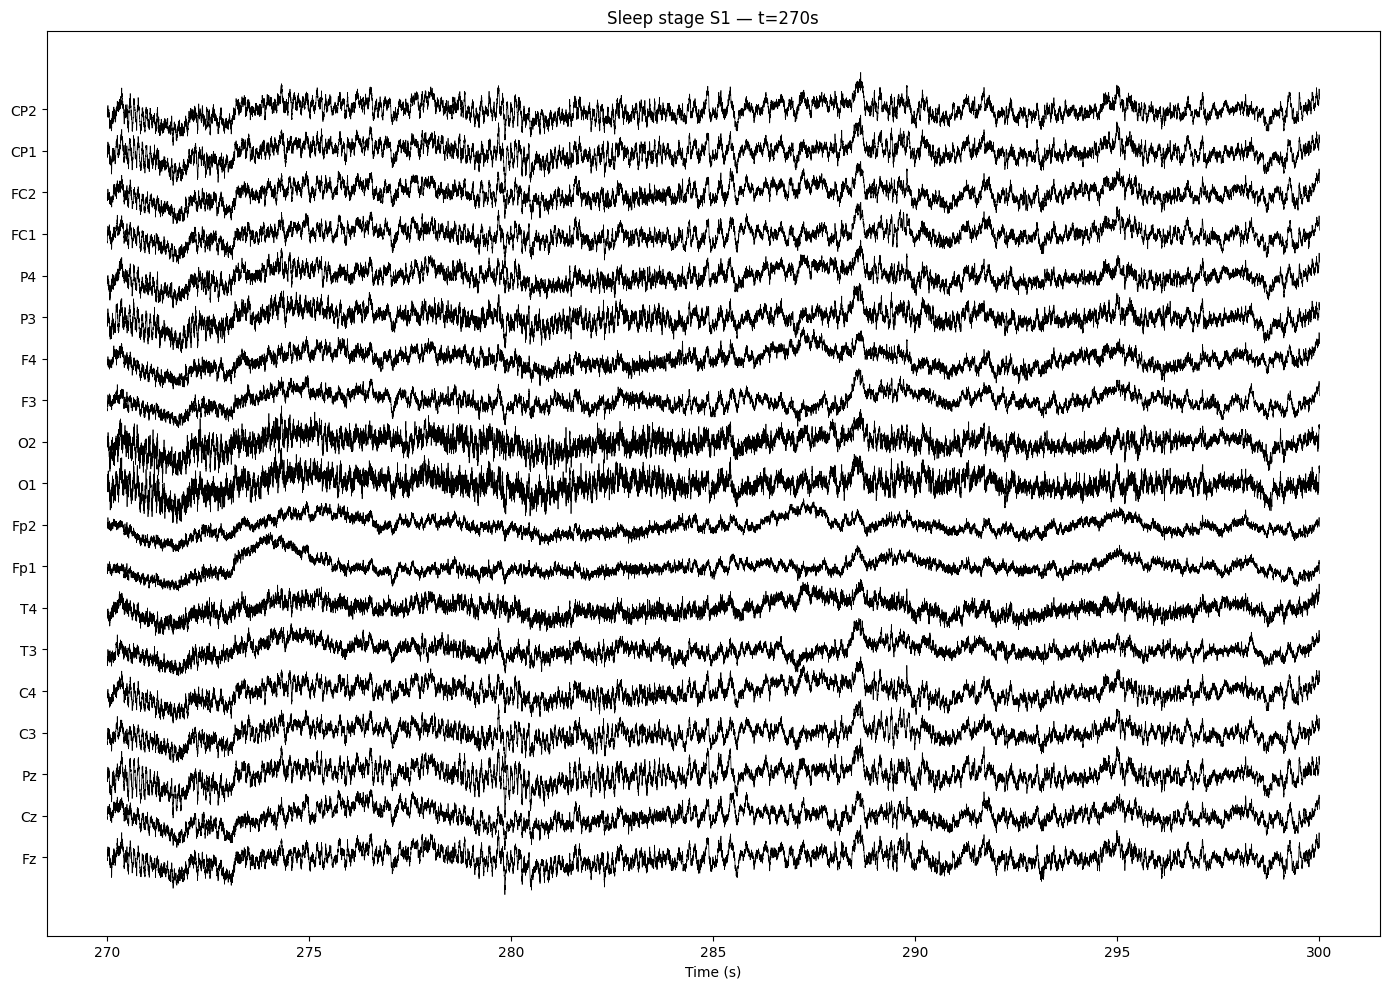

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
import matplotlib.pyplot as plt
import numpy as np
from mne_bids import BIDSPath, read_raw_bids

bids_path = BIDSPath(subject='01', task='sleep', datatype='eeg',
                     root='/home/alouis/scratch/dream_bids/')
raw = read_raw_bids(bids_path, verbose=False)
raw.pick('eeg')
raw.load_data(verbose=False)

# Trouver le début du premier S1 (jbe ou per)
s1_onset = None
for ann in raw.annotations:
    if 'Sleep stage S1' in ann['description']:
        s1_onset = ann['onset']
        break

print(f"Premier S1 à {s1_onset:.1f}s ({s1_onset/3600:.2f}h)")

# Plot
def plot_eeg_segment(raw, start_s, duration_s=30, n_ch=19, scale=50):
    start = int(start_s * raw.info['sfreq'])
    stop = int((start_s + duration_s) * raw.info['sfreq'])
    data, times = raw[:n_ch, start:stop]
    data_uv = data * 1e6
    fig, ax = plt.subplots(figsize=(14, 10))
    for i in range(n_ch):
        ax.plot(times, data_uv[i] / scale + i, 'k', lw=0.5)
    ax.set_yticks(range(n_ch))
    ax.set_yticklabels(raw.ch_names[:n_ch])
    ax.set_xlabel('Time (s)')
    ax.set_title(f'Sleep stage S1 — t={start_s:.0f}s')
    plt.tight_layout()
    return fig

fig = plot_eeg_segment(raw, start_s=s1_onset)
plt.show()

In [4]:
def plot_eeg_segment(raw, start_s, duration_s=30, n_ch=19, scale=50):
    start = int(start_s * raw.info['sfreq'])
    stop = int((start_s + duration_s) * raw.info['sfreq'])
    data, times = raw[:n_ch, start:stop]
    data_uv = data * 1e6

    fig, ax = plt.subplots(figsize=(14, 10))

    # Annotations dans la fenêtre seulement
    colors = {'jbe': 'steelblue', 'per': 'tomato'}
    for ann in raw.annotations:
        onset = ann['onset']
        dur = ann['duration']
        if onset + dur < start_s or onset > start_s + duration_s:
            continue
        scorer = ann['description'].split('/')[0]
        label = ann['description'].split('/')[-1]
        x0 = max(onset, start_s)
        x1 = min(onset + dur, start_s + duration_s)
        ax.axvspan(x0, x1, alpha=0.15, color=colors.get(scorer, 'gray'), label=f"{scorer}: {label}")

    for i in range(n_ch):
        ax.plot(times, data_uv[i] / scale + i, 'k', lw=0.5)

    ax.set_yticks(range(n_ch))
    ax.set_yticklabels(raw.ch_names[:n_ch])
    ax.set_xlabel('Time (s)')
    ax.set_title(f't={start_s:.0f}s')
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize=8)
    plt.tight_layout()
    return fig

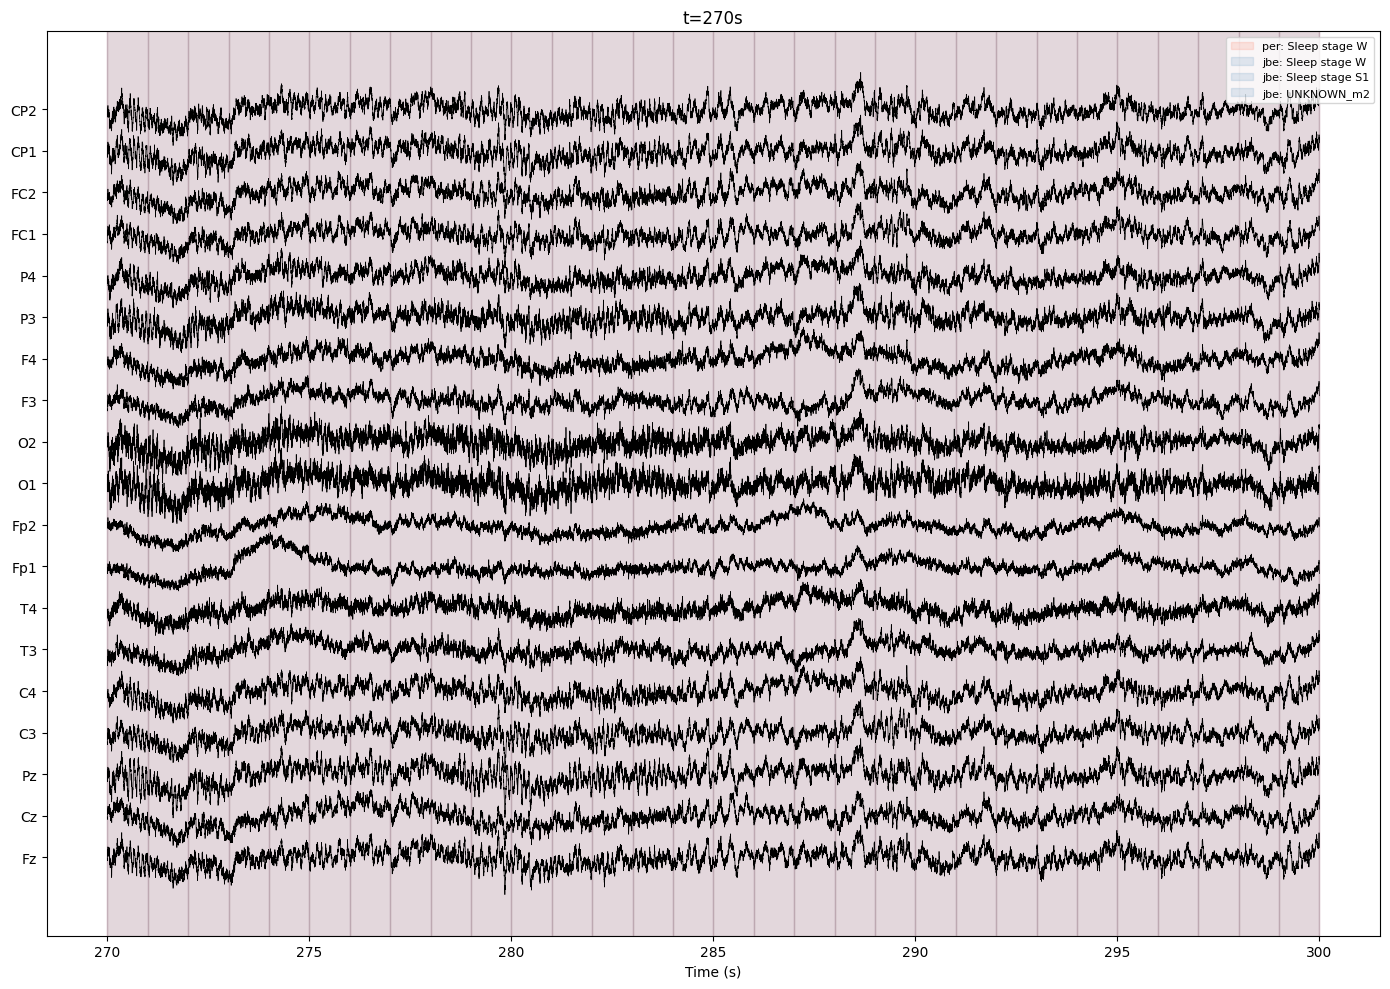

In [5]:
fig = plot_eeg_segment(raw, start_s=s1_onset)
plt.show()

Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


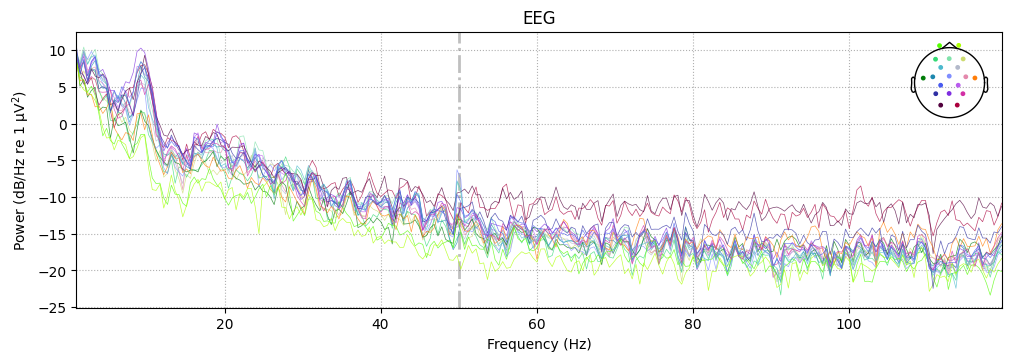

In [9]:
fig = raw.copy().crop(tmin=s1_onset, tmax=s1_onset+30).compute_psd(fmin=0.5, fmax=120, picks='eeg').plot(show=False)
plt.show()

In [ ]:
raw_preproc = raw.copy()
raw_preproc.notch_filter(freqs=[50, 100, 150], picks='eeg', verbose=False)
raw_preproc.filter(l_freq=0.1, h_freq=40., picks='eeg', verbose=False)

fig = raw_preproc.crop(tmin=s1_onset, tmax=s1_onset+30).compute_psd(fmin=0.5, fmax=40, picks='eeg').plot(show=False)
plt.show()